# Load Imports

In [80]:
import warnings
warnings.filterwarnings("ignore")

In [81]:
import pygenelab as pgl

In [82]:
import numpy as np
import pandas as pd
import scanpy as sc
import matplotlib.pyplot as plt

from pathlib import Path
from scipy import sparse
from scipy.stats import mannwhitneyu
from statsmodels.stats.multitest import multipletests

# Util Functions

In [83]:
def get_dense_matrix(X):
    """
    convert sparse matrix to dense numpy array
    """

    # get_dense_matrix
    # api:
    # get_dense_matrix(
    #     X=adata.X,
    # )

    if sparse.issparse(X):
        return X.toarray()

    return np.asarray(X)

In [84]:
def get_low_cv_genes(
    X,
    gene_names,
    n_bins=10,
    bottom_frac=0.10
):
    """
    select low-cv genes from expression matrix
    """

    # get_low_cv_genes
    # api:
    # get_low_cv_genes(
    #     X=X,
    #     gene_names=adata.var_names,
    #     n_bins=10,
    #     bottom_frac=0.10,
    # )

    means = X.mean(axis=0)
    stds = X.std(axis=0, ddof=1)

    cv = stds / (means + 1e-12)

    valid = np.isfinite(cv) & np.isfinite(means) & (means > 0)
    valid_idx = np.where(valid)[0]

    if len(valid_idx) == 0:
        return []

    mean_series = pd.Series(means[valid_idx], index=valid_idx)

    bins = pd.qcut(
        mean_series,
        q=n_bins,
        labels=False,
        duplicates="drop"
    )

    selected_idx = []

    for bin_id in sorted(bins.dropna().unique()):
        genes_in_bin = bins.index[bins == bin_id].to_numpy()

        if len(genes_in_bin) == 0:
            continue

        n_select = max(1, int(np.ceil(len(genes_in_bin) * bottom_frac)))

        bin_cv = cv[genes_in_bin]
        low_cv_idx = genes_in_bin[np.argsort(bin_cv)[:n_select]]

        selected_idx.extend(low_cv_idx)

    selected_idx = sorted(set(selected_idx))
    selected_genes = gene_names[selected_idx].tolist()

    return selected_genes


In [85]:
def calculate_noise_one_celltype(
    adata_ct,
    condition_col="condition",
    group1="WT",
    group2="KO",
    layer=None,
    max_cells=300,
    min_cells=10,
    n_bins=10,
    bottom_frac=0.10,
    random_state=1
):
    """
    calculate transcriptional noise for one cell type
    """

    # calculate_noise_one_celltype
    # api:
    # noise_df, summary = calculate_noise_one_celltype(
    #     adata_ct=adata_ct,
    #     condition_col="condition",
    #     group1="WT",
    #     group2="KO",
    #     layer=None,
    # )

    rng = np.random.default_rng(random_state)

    # get cells from each condition
    group1_cells = adata_ct.obs_names[
        adata_ct.obs[condition_col] == group1
    ].to_numpy()

    group2_cells = adata_ct.obs_names[
        adata_ct.obs[condition_col] == group2
    ].to_numpy()

    # sample equal number of cells
    n_sample = min(len(group1_cells), len(group2_cells), max_cells)

    if n_sample < min_cells:
        summary = {
            "status": "skipped",
            "reason": "not enough cells",
            f"n_{group1}_available": len(group1_cells),
            f"n_{group2}_available": len(group2_cells)
        }

        return None, summary

    group1_sample = rng.choice(
        group1_cells,
        size=n_sample,
        replace=False
    )

    group2_sample = rng.choice(
        group2_cells,
        size=n_sample,
        replace=False
    )

    selected_cells = np.concatenate([group1_sample, group2_sample])
    adata_sub = adata_ct[selected_cells, :].copy()

    # get normalized expression matrix
    if layer is None:
        X = get_dense_matrix(adata_sub.X).astype(float)
    else:
        X = get_dense_matrix(adata_sub.layers[layer]).astype(float)

    # select low-cv genes
    low_cv_genes = get_low_cv_genes(
        X=X,
        gene_names=adata_sub.var_names,
        n_bins=n_bins,
        bottom_frac=bottom_frac
    )

    if len(low_cv_genes) == 0:
        summary = {
            "status": "skipped",
            "reason": "no low-cv genes found",
            f"n_{group1}_available": len(group1_cells),
            f"n_{group2}_available": len(group2_cells)
        }

        return None, summary

    # subset to low-cv genes
    gene_idx = adata_sub.var_names.get_indexer(low_cv_genes)
    X_lowcv = X[:, gene_idx]

    labels = adata_sub.obs[condition_col].to_numpy()
    cell_ids = adata_sub.obs_names.to_numpy()

    # split expression by condition
    X_group1 = X_lowcv[labels == group1]
    X_group2 = X_lowcv[labels == group2]

    ids_group1 = cell_ids[labels == group1]
    ids_group2 = cell_ids[labels == group2]

    # calculate average profile for each group
    mean_group1 = X_group1.mean(axis=0)
    mean_group2 = X_group2.mean(axis=0)

    # calculate euclidean distance from own group average
    noise_group1 = np.linalg.norm(X_group1 - mean_group1, axis=1)
    noise_group2 = np.linalg.norm(X_group2 - mean_group2, axis=1)

    # save per-cell results
    noise_df = pd.DataFrame({
        "cell_id": np.concatenate([ids_group1, ids_group2]),
        "condition": [group1] * len(noise_group1) + [group2] * len(noise_group2),
        "noise": np.concatenate([noise_group1, noise_group2])
    })

    # compare noise distributions
    pval = mannwhitneyu(
        noise_group1,
        noise_group2,
        alternative="two-sided"
    ).pvalue

    mean_noise_group1 = noise_group1.mean()
    mean_noise_group2 = noise_group2.mean()

    log2_ratio = np.log2(
        (mean_noise_group2 + 1e-12) / 
        (mean_noise_group1 + 1e-12)
    )

    summary = {
        "status": "done",
        f"n_{group1}": n_sample,
        f"n_{group2}": n_sample,
        f"mean_noise_{group1}": mean_noise_group1,
        f"mean_noise_{group2}": mean_noise_group2,
        f"log2_{group2}_over_{group1}": log2_ratio,
        "pval": pval,
        "n_low_cv_genes": len(low_cv_genes)
    }

    return noise_df, summary

In [86]:
def plot_transcriptional_noise(
    noise_all_df,
    celltype_col="celltype",
    condition_col="condition",
    noise_col="noise",
    celltype_order=None,
    group_order=("WT", "KO"),
    figsize=(14, 5),
    title="WT vs KO Transcriptional Noise"
):
    """
    plot transcriptional noise boxplot
    """

    # plot_transcriptional_noise
    # api:
    # fig, ax = plot_transcriptional_noise(
    #     noise_all_df=noise_all_df,
    #     celltype_col="celltype",
    #     condition_col="condition",
    #     noise_col="noise",
    # )

    if celltype_order is None:
        celltype_order = noise_all_df[celltype_col].dropna().unique().tolist()

    plot_data = [
        noise_all_df[
            (noise_all_df[celltype_col] == celltype) &
            (noise_all_df[condition_col] == group)
        ][noise_col].dropna().values
        for celltype in celltype_order
        for group in group_order
    ]

    positions = []
    labels = []

    pos = 1
    for celltype in celltype_order:
        positions.extend([pos, pos + 0.7])
        labels.append(celltype)
        pos += 2.2

    fig, ax = plt.subplots(figsize=figsize)

    bp = ax.boxplot(
        plot_data,
        positions=positions,
        widths=0.5,
        patch_artist=True,
        showfliers=False
    )

    colors = {
        group_order[0]: "#50BA47",
        group_order[1]: "#A15DBA"
    }

    for i, box in enumerate(bp["boxes"]):
        group = group_order[i % len(group_order)]
        box.set_facecolor(colors[group])
        box.set_alpha(0.8)

    # set x-axis labels between each WT/KO pair
    tick_positions = [
        np.mean(positions[i:i + 2])
        for i in range(0, len(positions), 2)
    ]

    ax.set_xticks(tick_positions)
    ax.set_xticklabels(celltype_order, rotation=90)

    ax.set_ylabel("Transcriptional noise")
    ax.set_xlabel("Cell type")
    ax.set_title(title)

    # add legend
    legend_handles = [
        plt.Line2D(
            [0],
            [0],
            color=colors[group],
            lw=8,
            label=group
        )
        for group in group_order
    ]

    ax.legend(
        handles=legend_handles,
        title=condition_col,
        frameon=False
    )

    plt.tight_layout()

    return fig, ax

# Load Dataset

In [87]:
UPDATED_MICE_DATASET_PATH = "/ocean/projects/cis240075p/asachan/datasets/TA_muscle/ERCC1_KO_mice/integrated_samples/objects/adata_harmony_v2_re_annot.h5ad"
adata = sc.read_h5ad(UPDATED_MICE_DATASET_PATH)

In [88]:
# columns to use
celltype_col = "re_annot"
condition_col = "condition"

# groups to compare
group1 = "WT"
group2 = "KO"

layer = None

In [89]:
cell_types = adata.obs["re_annot"].unique().to_list()
cell_types

['Fast IIX',
 'Fast IIB',
 'NMJ',
 'Fast IIA',
 'MTJ-IIA',
 'FAPs',
 'Pericyte',
 'MTJ-IIX',
 'MTJ-IIB',
 'Macrophages',
 'EC',
 'Skeleton MuSc',
 'Tendon']

In [90]:
SEX = "M"
if SEX == "F" or SEX == "M":
    adata = pgl.subset_adata_by_obs(adata, filters={"sex": SEX})
adata.obs["sex"].value_counts()

sex
M    44171
Name: count, dtype: int64

# Calculate Transcriptional Noise

In [91]:
all_noise = []
all_summary = []

for celltype in cell_types:
    print(f"processing: {celltype}")

    # subset one cell type
    adata_ct = adata[
        adata.obs[celltype_col] == celltype
    ].copy()

    # calculate noise
    noise_df, summary = calculate_noise_one_celltype(
        adata_ct=adata_ct,
        condition_col=condition_col,
        group1=group1,
        group2=group2,
        layer=layer,
        max_cells=300,
        min_cells=10,
        n_bins=10,
        bottom_frac=0.10,
        random_state=1
    )

    # store summary
    summary["celltype"] = celltype
    all_summary.append(summary)

    # store per-cell noise values
    if noise_df is not None:
        noise_df["celltype"] = celltype
        all_noise.append(noise_df)

# combine results
noise_all_df = pd.concat(all_noise, ignore_index=True)
summary_df = pd.DataFrame(all_summary)

# adjust p-values
done_mask = summary_df["status"] == "done"

summary_df.loc[done_mask, "padj"] = multipletests(
    summary_df.loc[done_mask, "pval"],
    method="fdr_bh"
)[1]

summary_df["significant"] = summary_df["padj"] < 0.05

# sort summary
summary_df = summary_df.sort_values(
    f"log2_{group2}_over_{group1}",
    ascending=False,
    na_position="last"
)

summary_df

processing: Fast IIX
processing: Fast IIB
processing: NMJ
processing: Fast IIA
processing: MTJ-IIA
processing: FAPs
processing: Pericyte
processing: MTJ-IIX
processing: MTJ-IIB
processing: Macrophages
processing: EC
processing: Skeleton MuSc


processing: Tendon


,status,n_WT,n_KO,mean_noise_WT,mean_noise_KO,log2_KO_over_WT,pval,n_low_cv_genes,celltype,padj,significant
4,done,65,65,8.911132,9.363696,0.071469,0.040942,140,MTJ-IIA,0.119319,False
3,done,300,300,8.852579,9.041904,0.030529,0.078658,189,Fast IIA,0.146080,False
0,done,300,300,8.668920,8.827832,0.026207,0.285511,190,Fast IIX,0.371165,False
2,done,186,186,9.589889,9.677629,0.013140,0.516656,200,NMJ,0.559711,False
1,done,300,300,8.743906,8.757427,0.002229,0.983278,190,Fast IIB,0.983278,False
11,done,300,300,12.821511,12.695627,-0.014235,0.366688,220,Skeleton MuSc,0.433358,False
6,done,300,300,13.725447,13.547671,-0.018808,0.077544,220,Pericyte,0.146080,False
9,done,300,300,12.638393,12.461778,-0.020303,0.203719,231,Macrophages,0.331044,False
12,done,300,300,12.813452,12.598386,-0.024420,0.275851,250,Tendon,0.371165,False
5,done,300,300,14.811997,14.545189,-0.026224,0.045892,240,FAPs,0.119319,False


# Plot

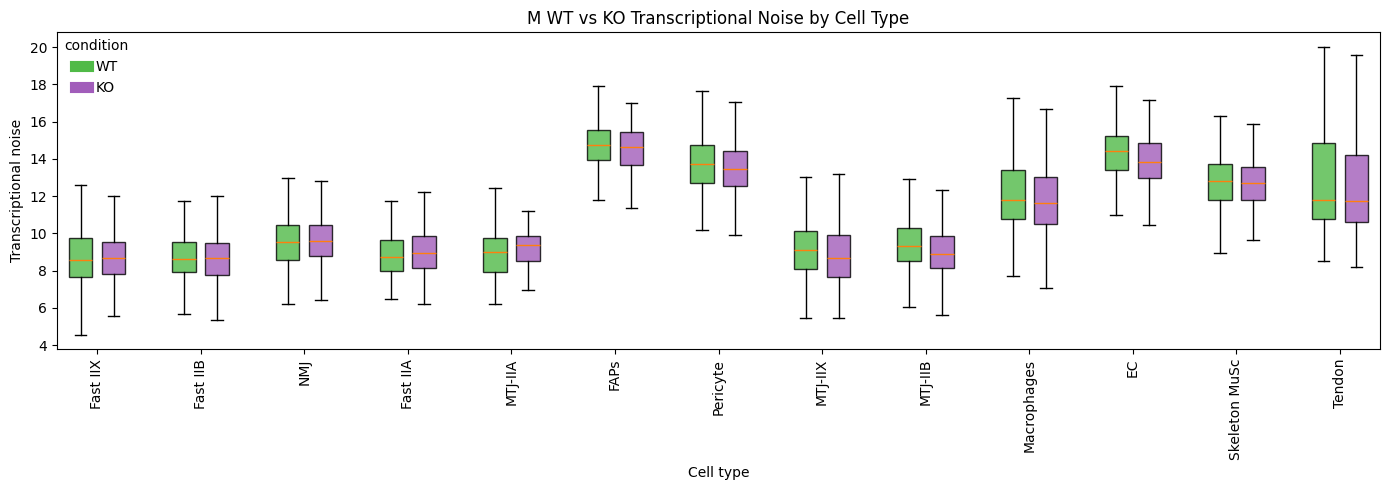

In [92]:
fig, ax = plot_transcriptional_noise(
    noise_all_df=noise_all_df,
    celltype_col="celltype",
    condition_col="condition",
    noise_col="noise",
    celltype_order=cell_types,
    group_order=(group1, group2),
    figsize=(14, 5),
    title=f"{SEX} WT vs KO Transcriptional Noise by Cell Type"
)

plt.show()

# Save Plot

In [93]:
output_dir = Path("Output")
output_dir.mkdir(parents=True, exist_ok=True)

In [94]:
# save plot
png_path = output_dir / f"{SEX}_WT_vs_KO_Transcriptional_Noise_PNG.png"
svg_path = output_dir / f"{SEX}_WT_vs_KO_Transcriptional_Noise_SVG.svg"

pgl.save_fig_as_png(fig, png_path)
pgl.save_editable_svg(fig, svg_path)

PosixPath('Output/M_WT_vs_KO_Transcriptional_Noise_SVG.svg')

PosixPath('Output/M_WT_vs_KO_Transcriptional_Noise_Stats_SVG.svg')

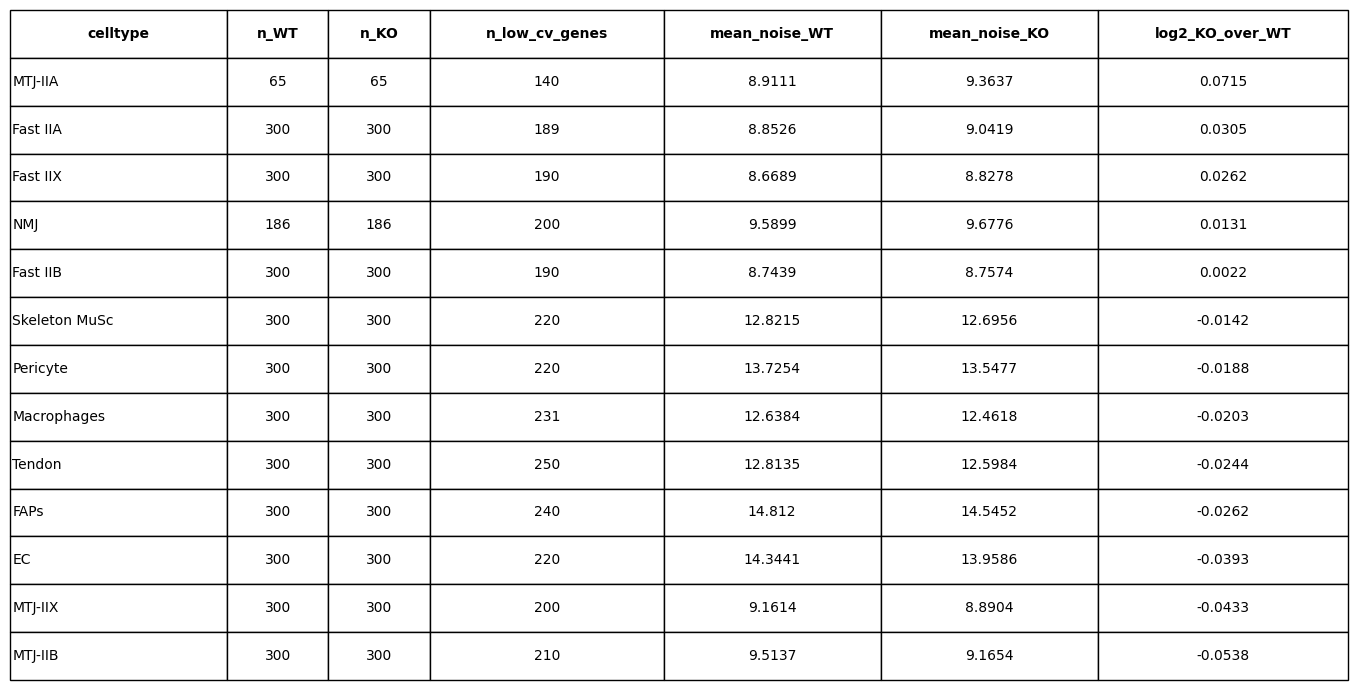

In [95]:
# save stats
stats_df = summary_df[["celltype", "n_WT", "n_KO", "n_low_cv_genes", "mean_noise_WT", "mean_noise_KO", "log2_KO_over_WT"]]

stats_png_path = output_dir / f"{SEX}_WT_vs_KO_Transcriptional_Noise_Stats_PNG.png"
stats_svg_path = output_dir / f"{SEX}_WT_vs_KO_Transcriptional_Noise_Stats_SVG.svg"

stats_fig = pgl.save_df_table_image(stats_df)

pgl.save_fig_as_png(stats_fig, stats_png_path)
pgl.save_editable_svg(stats_fig, stats_svg_path)